In [1]:
import os
from tensorflow.keras.datasets import imdb

num_words = 10000
(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=num_words)
print(f"训练集样本数: {len(x_train)}")
print(f"测试集样本数: {len(x_test)}")
print(f"训练集标签示例: {y_train[:10]}")
print(f"测试集标签示例: {y_test[:10]}")
      
word_index = imdb.get_word_index()
word_index = {k:(v+3) for k,v in word_index.items()}
word_index.update({"<PAD>":0,"<START>":1,"<UNK>":2,"<UNUSED>":3})
print(x_train[1])

训练集样本数: 25000
测试集样本数: 25000
训练集标签示例: [1 0 0 1 0 0 1 0 1 0]
测试集标签示例: [0 1 1 0 1 1 1 0 0 1]
[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 8163, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 6853, 5, 163, 11, 3215, 2, 4, 1153, 9, 194, 775, 7, 8255, 2, 349, 2637, 148, 605, 2, 8003, 15, 123, 125, 68, 2, 6853, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 2, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 8255, 5, 2, 656, 245, 2350, 5, 4, 9837, 131, 152, 491, 18, 2, 32, 7464, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]


In [2]:
index_to_word = {v:k for k,v in word_index.items()}
def decode_review(encoded_review):
    return " ".join(index_to_word.get(v,"?") for v in encoded_review)

print(decode_review(x_train[0]))

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha

In [3]:
import numpy as np
x_val = x_test[:10000]
y_val = y_test[:10000]

x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")


验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


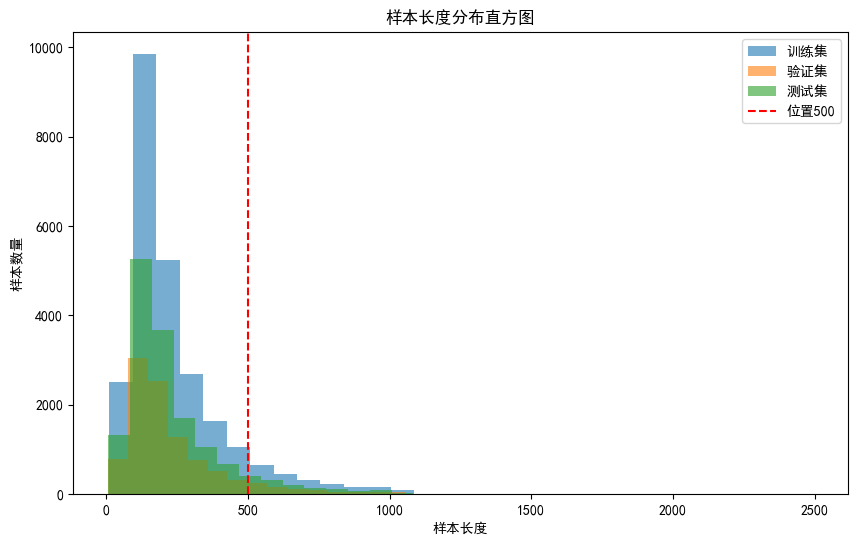

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei'] # 显示中文标签
matplotlib.rcParams['axes.unicode_minus'] = False   # 正常显示负号

# 计算所有样本的长度
train_lengths = [len(seq) for seq in x_train]
val_lengths = [len(seq) for seq in x_val]
test_lengths = [len(seq) for seq in x_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=30, alpha=0.6, label='训练集')
plt.hist(val_lengths, bins=30, alpha=0.6, label='验证集')
plt.hist(test_lengths, bins=30, alpha=0.6, label='测试集')
plt.axvline(x=500, color='r', linestyle='--', label='位置500')
plt.xlabel('样本长度')
plt.ylabel('样本数量')
plt.title('样本长度分布直方图')
plt.legend()
plt.show()


In [41]:
class Tokenizer:
    def __init__(self, word_index, index_to_word):
        self.word_index = word_index
        self.index_to_word = index_to_word
        self.vocab_size = len(word_index)
        
        self.pad_token = "<PAD>"
        self.bos_token = "<START>"
        self.unk_token = "<UNK>"
        self.eos_token = "<UNUSED>"

        self.pad_id = self.word_index[self.pad_token]
        self.bos_id = self.word_index[self.bos_token]
        self.unk_id = self.word_index[self.unk_token]
        self.eos_id = self.word_index[self.eos_token]
        
    def encode(self, text, maxlen=None, padding='post', truncating='post',add_bos=False, add_eos=False):
        if not isinstance(text, list):
            raise ValueError("输入文本必须是一个字符串列表")
                
        batch_max_len = max([len(seq) for seq in text])  # 计算批次中最长序列的长度
        if add_bos:
            batch_max_len += 1  # 如果添加起始符，最大长度加1
        if add_eos:
            batch_max_len += 1  # 如果添加结束符，最大长度加1
        
        if maxlen is None or maxlen > batch_max_len:
            maxlen = batch_max_len
        
        result = []
        for text in text:
            sequence = []
            
            if add_bos:
                sequence.append(self.bos_id)
            
            for word in text:
                sequence.append(self.word_index.get(word, self.unk_id))
            
            if add_eos:
                sequence.append(self.eos_id)
            
            if len(sequence) > maxlen:
                if truncating == 'post':
                    sequence = sequence[:maxlen]
                elif truncating == 'pre':
                    sequence = sequence[-maxlen:]
            else:
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'post':
                        sequence = sequence + [self.pad_id] * pad_length
                    elif padding == 'pre':
                        sequence = [self.pad_id] * pad_length + sequence
                        
            result.append(sequence)
        
        return np.array(result)
    
    def decode(self, ids, skip_special_tokens=True):
        results = []
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}
        for seq in ids:
            tokens = []
            for idx in seq:
                token = self.index_to_word.get(idx, self.unk_token)
                if skip_special_tokens and token in special_tokens:
                    continue
                tokens.append(token)
            results.append(' '.join(tokens))

        return results

raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
decoded_text = tokenizer.decode(encoded_text)

a,b=zip(('a',1),('b',1),('c',0))

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = tokenizer.decode(texts)
        self.labels = labels
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

def collate_fn(batch,max_len = 500):
    texts, labels = zip(*batch)
    token_lists = [text.split() for text in texts]
    encoded_batch = tokenizer.encode(token_lists,maxlen=max_len,padding='pre', add_bos=False, add_eos=True)
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

train_dataset = TextDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

for batch_texts, batch_labels in train_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    print(batch_texts)
    print(batch_labels)
    decoded_texts = tokenizer.decode(batch_texts.tolist())
    print(decoded_texts)
    break

for batch_texts, batch_labels in val_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    break

for batch_texts, batch_labels in test_dataloader:
    print(batch_texts.shape)
    print(batch_labels.shape)
    break

torch.Size([64, 500])
torch.Size([64])
tensor([[   0,    0,    0,  ...,    6,   20,    3],
        [   0,    0,    0,  ..., 2460, 3645,    3],
        [   0,    0,    0,  ...,   11,  748,    3],
        ...,
        [ 377, 3164, 4818,  ...,  137,  112,  324],
        [   0,    0,    0,  ...,   53,  139,    3],
        [   0,    0,    0,  ...,    6,  356,    3]])
tensor([0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1])
["i saw this movie on t v this afternoon and i can't see how anyone can sit through this piece of trash it's not funny at all and it takes your i q down a few <UNK> i know this movie is for kids but that doesn't mean the writers should take their intelligence for granted i bet that writers were sitting around a large wooden table and figured that a the word <UNK> equals big laugh b a four foot tall kid can <UNK> on

In [43]:
import torch
import torch.nn as nn

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=1, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.bidirectional = bidirectional
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=rnn_layers,
            batch_first=True,
            nonlinearity='tanh',
            bidirectional=bidirectional
        )
        rnn_output_dim = hidden_dim * (2 if bidirectional else 1)
        # 2层线性
        self.fc1 = nn.Linear(rnn_output_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        # 嵌入层
        embedded = self.embedding(x)
        # RNN层
        rnn_out, h_n = self.rnn(embedded)
        # 取最后一个时间步的输出
        if self.bidirectional:
            last_layer_h_n = h_n[-2:,:,:]   # shape: (2, batch, hidden_dim)
            last_output = torch.cat([last_layer_h_n[0], last_layer_h_n[1]], dim=-1)
        else:
            last_output = h_n[-1]
        # 全连接层
        out = self.fc1(last_output)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [44]:
vocab_size = num_words
embedding_dim = 16
hidden_dim = 64
num_classes = 1
rnn_layers = 1
bidirectional = False

model = TextClassifier(vocab_size, embedding_dim, hidden_dim, num_classes, rnn_layers=rnn_layers, bidirectional=bidirectional)

batch_size = 2
seq_length = 10
x = torch.randint(0, vocab_size, (batch_size, seq_length),dtype=torch.long)
print(x.shape)
with torch.no_grad():
    outputs = model(x)
    print(outputs.shape)
    print(outputs)

torch.Size([2, 10])
torch.Size([2, 1])
tensor([[-0.1177],
        [ 0.0080]])


In [45]:
total_params = 0
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"total_params: {total_params}")

len(train_dataloader)

embedding.weight: 160000
rnn.weight_ih_l0: 1024
rnn.weight_hh_l0: 4096
rnn.bias_ih_l0: 64
rnn.bias_hh_l0: 64
fc1.weight: 4096
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
total_params: 169473


391

In [46]:
from torch import device
import my_trainer_RNN as mt

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

early_stopping = mt.EarlyStopping(patience=5, min_delta=0.01,mode='max')

trainer = mt.Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,
    # early_stopping=early_stopping,
)

num_epochs = 20
trainer.train_binary(num_epochs)


[Step 100] Val Loss: 0.6919 Val Acc: 0.5302
[Step 200] Val Loss: 0.6891 Val Acc: 0.5405
[Step 300] Val Loss: 0.6830 Val Acc: 0.5637
Epoch [1/20] Train Loss: 0.6886 Acc: 0.5388 | Val Loss: 0.6830 Val Acc: 0.5637
[Step 400] Val Loss: 0.6773 Val Acc: 0.5758
[Step 500] Val Loss: 0.6698 Val Acc: 0.5869
[Step 600] Val Loss: 0.6675 Val Acc: 0.5929
[Step 700] Val Loss: 0.6598 Val Acc: 0.6067
Epoch [2/20] Train Loss: 0.6705 Acc: 0.5871 | Val Loss: 0.6598 Val Acc: 0.6067
[Step 800] Val Loss: 0.6641 Val Acc: 0.5979
[Step 900] Val Loss: 0.6558 Val Acc: 0.6098
[Step 1000] Val Loss: 0.6480 Val Acc: 0.6220
[Step 1100] Val Loss: 0.6638 Val Acc: 0.5946
Epoch [3/20] Train Loss: 0.6533 Acc: 0.6153 | Val Loss: 0.6638 Val Acc: 0.5946
[Step 1200] Val Loss: 0.6513 Val Acc: 0.6132
[Step 1300] Val Loss: 0.6478 Val Acc: 0.6210
[Step 1400] Val Loss: 0.6389 Val Acc: 0.6315
[Step 1500] Val Loss: 0.6338 Val Acc: 0.6470
Epoch [4/20] Train Loss: 0.6387 Acc: 0.6320 | Val Loss: 0.6338 Val Acc: 0.6470
[Step 1600] Val Lo

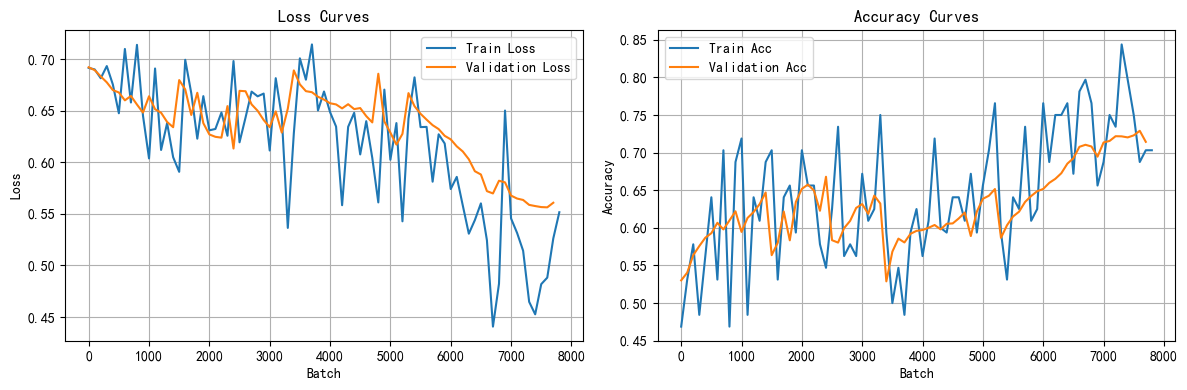

In [48]:
trainer.plot_curves(sample_step=100)